# Task 1 - Day 1: Data Cleaning & Preprocessing

### Objective:
Learn how to clean and prepare raw data for ML models.

### Tools:
Python, Pandas, NumPy, Matplotlib, Seaborn

## Step 1: Imports and Loading the Dataset
We import standard packages and load the Titanic dataset from Seaborn (with a fallback URL to GitHub if Seaborn cannot download it).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create directory for plots
os.makedirs('plots', exist_ok=True)

try:
    df = sns.load_dataset('titanic')
    print("Loaded Titanic dataset successfully from Seaborn.")
except Exception as e:
    print(f"Failed to load via Seaborn ({e}). Attempting download from GitHub...")
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    print("Loaded Titanic dataset from GitHub successfully.")

Loaded Titanic dataset successfully from Seaborn.


## Step 2: Exploratory Data Analysis (EDA)
We investigate the dataset's basic info, shapes, data types, and check for missing values.

In [2]:
print(f"Dataset Shape: {df.shape}\n")
print("Columns and Data Types:")
print(df.dtypes)

print("\nMissing Values Count per Column:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

Dataset Shape: (891, 15)

Columns and Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values Count per Column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


## Step 3: Handling Missing Values
- Drop column `deck` since it contains >70% nulls.
- Impute missing values for `age` using its median.
- Impute missing values for `embarked` and `embark_town` using their modes.
- Drop redundant/collinear columns (`alive`, `alone`, `class`, `who`, `adult_male`, `embark_town`).

In [3]:
# Drop deck column
if 'deck' in df.columns:
    print("Dropping 'deck' column.")
    df.drop(columns=['deck'], inplace=True)

# Impute age with median
if 'age' in df.columns:
    age_median = df['age'].median()
    print(f"Imputing age with median: {age_median}")
    df['age'].fillna(age_median, inplace=True)
elif 'Age' in df.columns:
    age_median = df['Age'].median()
    print(f"Imputing Age with median: {age_median}")
    df['Age'].fillna(age_median, inplace=True)

# Impute embarked with mode
for col in ['embarked', 'embark_town', 'Embarked']:
    if col in df.columns:
        col_mode = df[col].mode()[0]
        print(f"Imputing {col} with mode: {col_mode}")
        df[col].fillna(col_mode, inplace=True)

# Drop redundant columns
redundant_cols = ['embark_town', 'alive', 'alone', 'class', 'who', 'adult_male']
for r_col in redundant_cols:
    if r_col in df.columns:
        print(f"Dropping redundant column: {r_col}")
        df.drop(columns=[r_col], inplace=True)

# Normalize column names if Kaggle dataset was loaded
name_mapping = {
    'Survived': 'survived', 'Pclass': 'pclass', 'Sex': 'sex',
    'Age': 'age', 'SibSp': 'sibsp', 'Parch': 'parch',
    'Fare': 'fare', 'Embarked': 'embarked'
}
df.rename(columns={k: v for k, v in name_mapping.items() if k in df.columns}, inplace=True)

# Select primary variables
keep_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[[c for c in keep_cols if c in df.columns]]

print("\nMissing values after imputation:")
print(df.isnull().sum())

Dropping 'deck' column.
Imputing age with median: 28.0
Imputing embarked with mode: S
Imputing embark_town with mode: Southampton
Dropping redundant column: embark_town
Dropping redundant column: alive
Dropping redundant column: alone
Dropping redundant column: class
Dropping redundant column: who
Dropping redundant column: adult_male

Missing values after imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


/var/folders/32/0vnbsy950k38gmd616wxxmgh0000gn/T/ipykernel_78125/2903904379.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(age_median, inplace=True)
/var/folders/32/0vnbsy950k38gmd616wxxmgh0000gn/T/ipykernel_78125/2903904379.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

## Step 4: Outlier Detection and Visualization
We visualize the outliers of `age` and `fare` using boxplots before outlier removal.

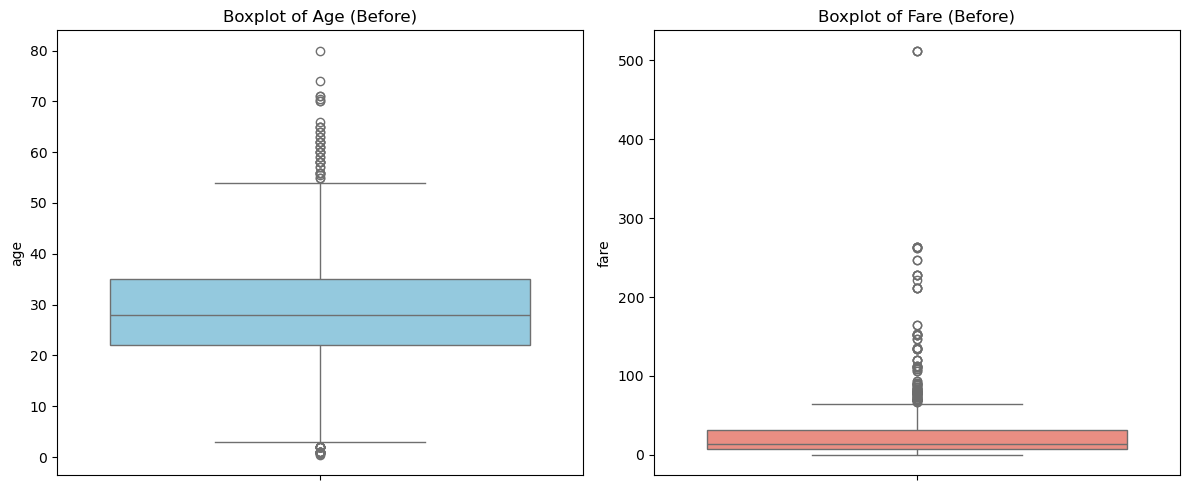

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['age'], color='skyblue')
plt.title('Boxplot of Age (Before)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['fare'], color='salmon')
plt.title('Boxplot of Fare (Before)')

plt.tight_layout()
plt.savefig('plots/outliers_before.png', dpi=150)
plt.show()

## Step 5: Handling Outliers (IQR Method)
Using the Interquartile Range (IQR) method, we clean the outliers from the dataset.

Age IQR: 13.00, bounds: [2.50, 54.50]
Fare IQR: 23.09, bounds: [-26.72, 65.63]
Removed 170 outlier rows. Remaining rows: 721


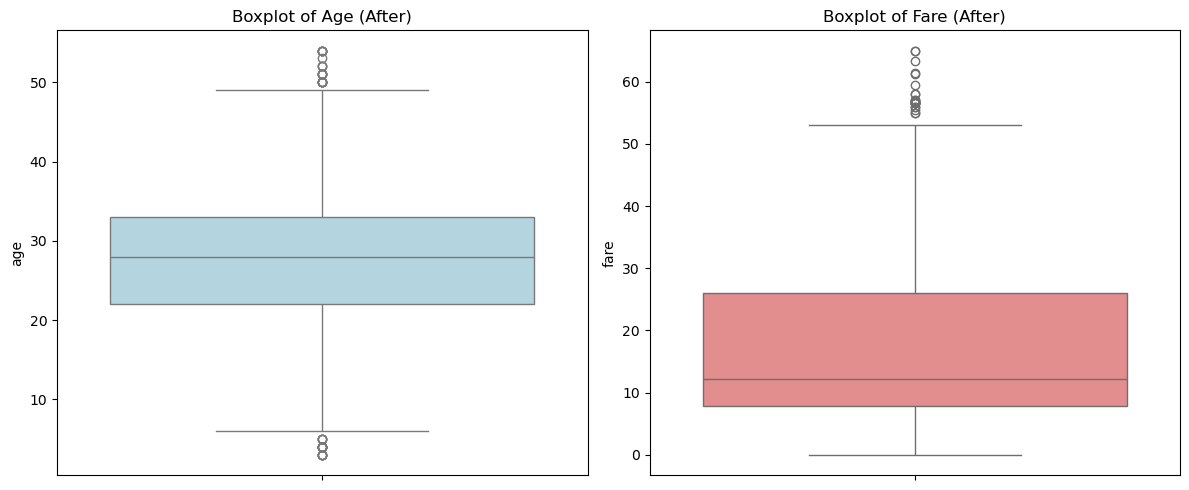

In [5]:
# Calculate IQR and bounds for age
q1_age = df['age'].quantile(0.25)
q3_age = df['age'].quantile(0.75)
iqr_age = q3_age - q1_age
lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age
print(f"Age IQR: {iqr_age:.2f}, bounds: [{lower_age:.2f}, {upper_age:.2f}]")

# Calculate IQR and bounds for fare
q1_fare = df['fare'].quantile(0.25)
q3_fare = df['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare
print(f"Fare IQR: {iqr_fare:.2f}, bounds: [{lower_fare:.2f}, {upper_fare:.2f}]")

# Filter outliers
before_count = len(df)
df_cleaned = df[
    (df['age'] >= lower_age) & (df['age'] <= upper_age) &
    (df['fare'] >= lower_fare) & (df['fare'] <= upper_fare)
].copy()

after_count = len(df_cleaned)
print(f"Removed {before_count - after_count} outlier rows. Remaining rows: {after_count}")

# Plot outliers after removal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['age'], color='lightblue')
plt.title('Boxplot of Age (After)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['fare'], color='lightcoral')
plt.title('Boxplot of Fare (After)')

plt.tight_layout()
plt.savefig('plots/outliers_after.png', dpi=150)
plt.show()

## Step 6: Categorical Encoding
We convert categorical features (`sex`, `embarked`) into numerical representations using One-Hot Encoding.

In [6]:
print("Applying One-Hot Encoding to 'sex' and 'embarked'...")
df_encoded = pd.get_dummies(df_cleaned, columns=['sex', 'embarked'], drop_first=True)

# Convert boolean to int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encoded columns:", df_encoded.columns.tolist())
df_encoded.head()

Applying One-Hot Encoding to 'sex' and 'embarked'...
Encoded columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1
5,0,3,28.0,0,0,8.4583,1,1,0


## Step 7: Feature Scaling
We normalize/standardize the numerical features (`age` and `fare`). We demonstrate standard scaling (mean=0, std=1) and Min-Max scaling (range=[0, 1]).

In [7]:
# Z-score scaling
df_encoded['age_standardized'] = (df_encoded['age'] - df_encoded['age'].mean()) / df_encoded['age'].std()
df_encoded['fare_standardized'] = (df_encoded['fare'] - df_encoded['fare'].mean()) / df_encoded['fare'].std()

# Min-max scaling
df_encoded['age_minmax'] = (df_encoded['age'] - df_encoded['age'].min()) / (df_encoded['age'].max() - df_encoded['age'].min())
df_encoded['fare_minmax'] = (df_encoded['fare'] - df_encoded['fare'].min()) / (df_encoded['fare'].max() - df_encoded['fare'].min())

print("Scaled columns statistics:")
print(df_encoded[['age', 'age_standardized', 'age_minmax', 'fare', 'fare_standardized', 'fare_minmax']].describe().loc[['mean', 'std', 'min', 'max']])

Scaled columns statistics:
            age  age_standardized  age_minmax       fare  fare_standardized  \
mean  28.094313     -2.020267e-16    0.492045  17.389845       5.420229e-17   
std   10.021961      1.000000e+00    0.196509  13.563036       1.000000e+00   
min    3.000000     -2.503932e+00    0.000000   0.000000      -1.282150e+00   
max   54.000000      2.584892e+00    1.000000  65.000000       3.510287e+00   

      fare_minmax  
mean     0.267536  
std      0.208662  
min      0.000000  
max      1.000000  


## Step 8: Exporting Cleaned Dataset
Finally, we save our cleaned and preprocessed dataset to `cleaned_titanic.csv`.

In [8]:
output_path = 'cleaned_titanic.csv'
df_encoded.to_csv(output_path, index=False)
print(f"Saved cleaned & preprocessed dataset to '{output_path}'. Final shape: {df_encoded.shape}")

Saved cleaned & preprocessed dataset to 'cleaned_titanic.csv'. Final shape: (721, 13)
